In [1]:
%cd ..

/home/bhchen/LearnKalmanGain


--- Starting Data Averaging Process ---
Successfully created: data/lorenz63/pf_results_sigma_y_1.0_batch_64_len_500_pfN_1000_avg.pt
Successfully created: data/lorenz63/pf_results_sigma_y_1.0_batch_64_len_500_pfN_2000_avg.pt
Successfully created: data/lorenz63/pf_results_sigma_y_1.0_batch_64_len_500_pfN_5000_avg.pt
Successfully created: data/lorenz63/pf_results_sigma_y_1.0_batch_64_len_500_pfN_10000_avg.pt
Successfully created: data/lorenz63/pf_results_sigma_y_1.0_batch_64_len_500_pfN_20000_avg.pt
Successfully created: data/lorenz63/pf_results_sigma_y_1.0_batch_64_len_500_pfN_50000_avg.pt
Successfully created: data/lorenz63/pf_results_sigma_y_1.0_batch_64_len_500_pfN_100000_avg.pt

--- Data Averaging Complete ---

--- Starting Plotting Process ---
Results for T=15.00, pf_N=100000:
  SE of Mean (RMSE-based): 0.112088
  SE of Cov (F-norm-based): 0.105534
  SE of Mean (Relative RMSE): 0.00874342
  SE of Cov (Relative F-norm): 0.0506681
Results for T=45.00, pf_N=100000:
  SE of Mean (RMSE-b

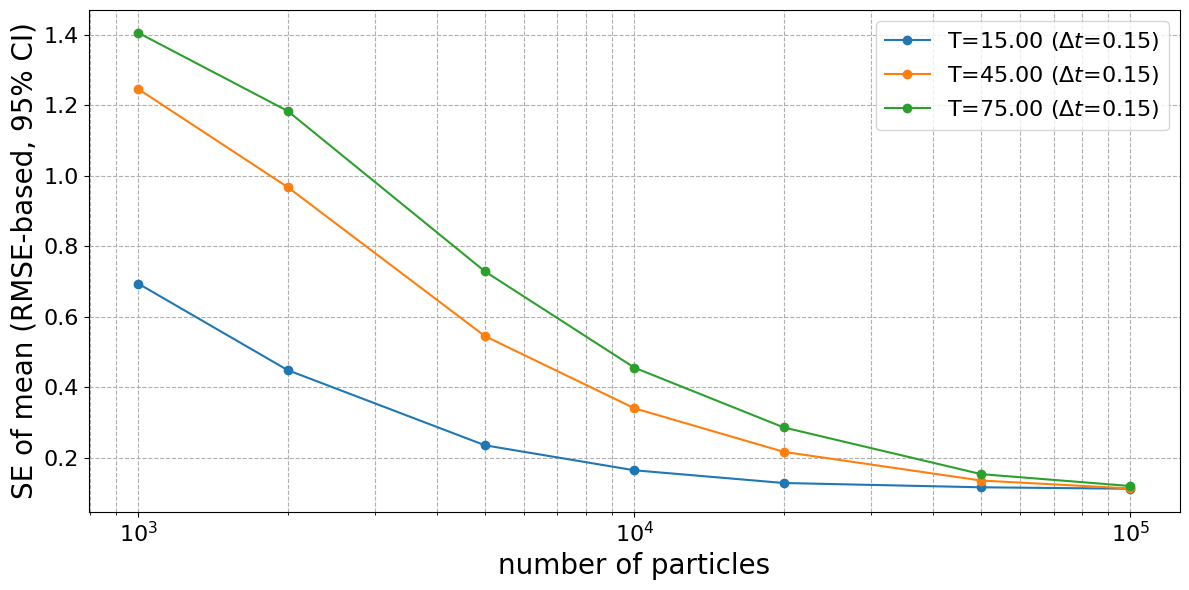

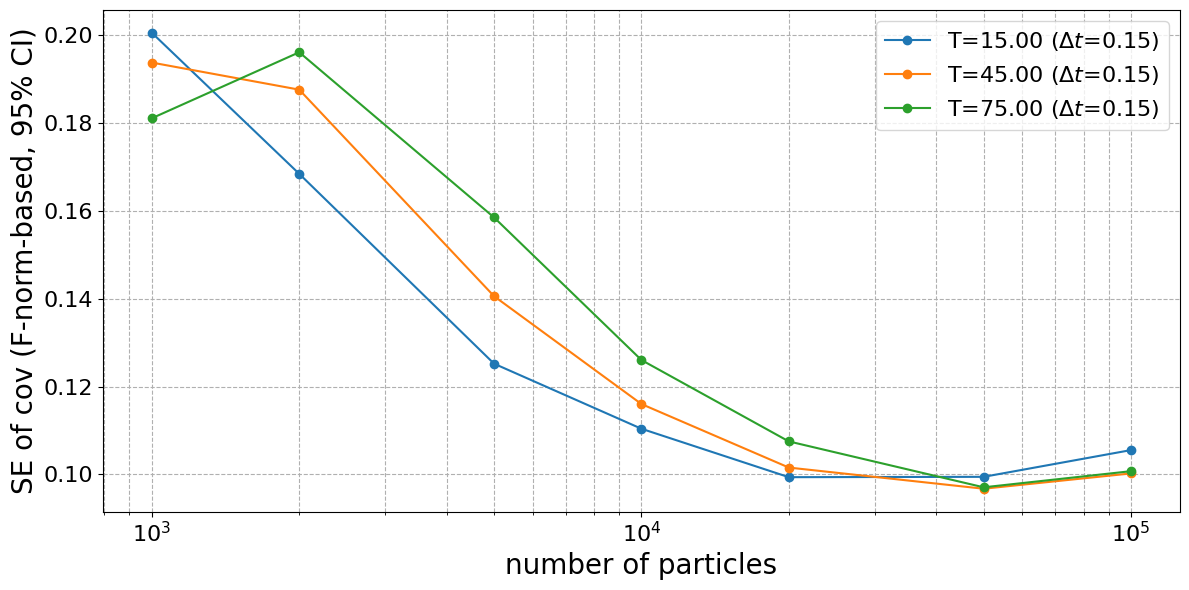

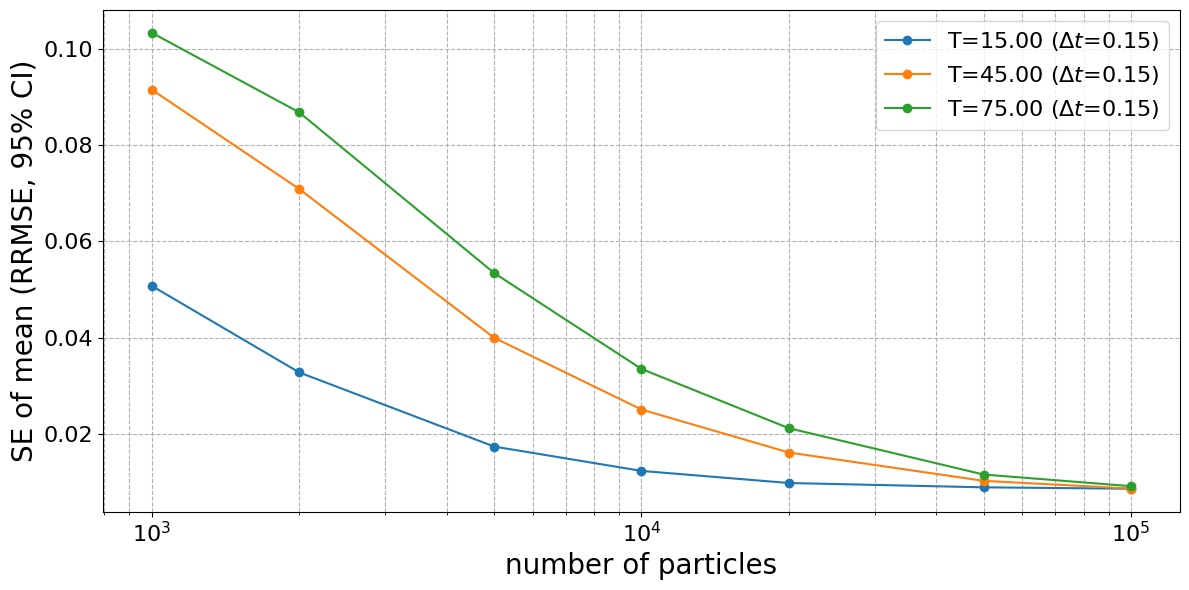

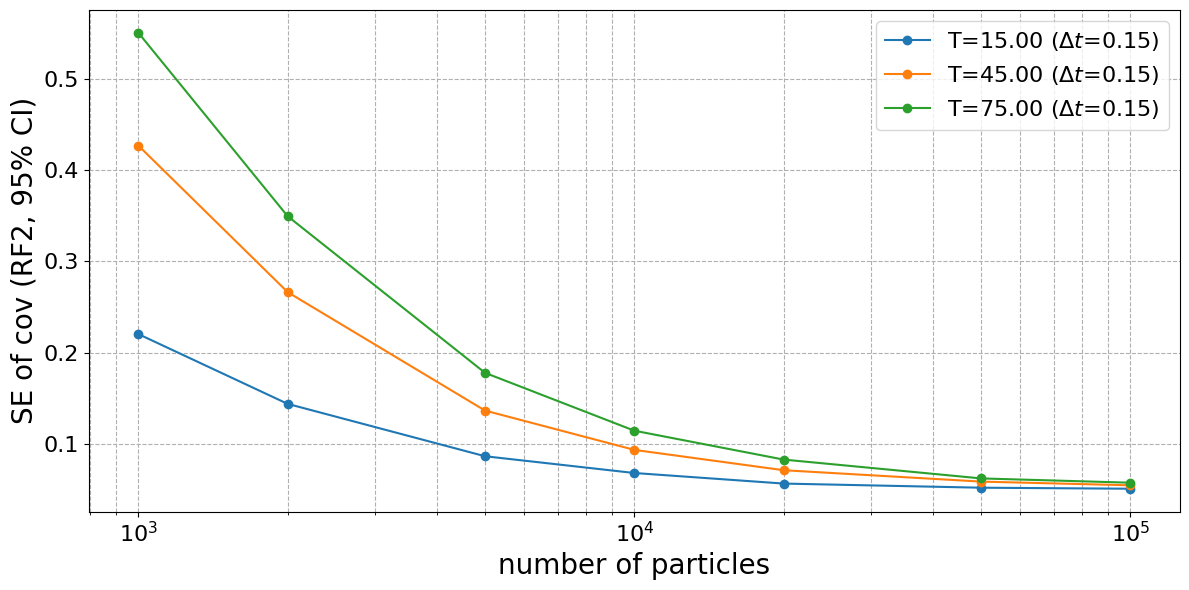


--- Plotting Complete ---


In [4]:
import torch
import os
import matplotlib.pyplot as plt
import math

# --- Configuration ---
pf_N_list = [1000, 2000, 5000, 10000, 20000, 50000, 100000]
seed_list = torch.arange(100)
max_t_list = [100, 300, 500]

# Make dataset name a variable and build data_dir via f-string
dataset = "lorenz63"
data_dir = f"data/{dataset}/"

dt = 0.15  # physical time step used only for legend labeling
eps = 1e-12  # small constant to avoid divide-by-zero in relative metrics

# --- Part 1: Average data across seeds and save new files ---
print("--- Starting Data Averaging Process ---")
os.makedirs(data_dir, exist_ok=True)

N_seeds = len(seed_list)

for pf_N in pf_N_list:
    mean_tensors = []
    cov_tensors = []

    for seed in seed_list:
        file_path = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_{seed}.pt"
        if os.path.exists(file_path):
            try:
                # NOTE: weights_only=True is fine if the file is a pure tensor container; otherwise consider removing it.
                data = torch.load(file_path, weights_only=True)
                mean_tensors.append(data[0]['means'])
                cov_tensors.append(data[0]['covs'])
            except Exception as e:
                print(f"Could not load or process file {file_path}: {e}")
        else:
            print(f"Warning: File not found and will be skipped: {file_path}")

    if not mean_tensors:
        print(f"No data found for pf_N = {pf_N}, skipping.")
        continue

    avg_mean = torch.mean(torch.stack(mean_tensors), dim=0)
    avg_cov = torch.mean(torch.stack(cov_tensors), dim=0)

    output_data = [{'means': avg_mean, 'covs': avg_cov}]
    output_path = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_avg.pt"
    torch.save(output_data, output_path)
    print(f"Successfully created: {output_path}")

print("\n--- Data Averaging Complete ---\n")

# --- Part 2: Calculate SE and Plot Results ---
print("--- Starting Plotting Process ---")

# Absolute metrics figures
fig1 = plt.figure(figsize=(12, 6))
fig2 = plt.figure(figsize=(12, 6))
ax1 = fig1.add_subplot(1, 1, 1)
ax2 = fig2.add_subplot(1, 1, 1)
ax1.set_xscale('log')
ax2.set_xscale('log')

# Relative metrics figures (NEW)
fig3 = plt.figure(figsize=(12, 6))
fig4 = plt.figure(figsize=(12, 6))
ax3 = fig3.add_subplot(1, 1, 1)
ax4 = fig4.add_subplot(1, 1, 1)
ax3.set_xscale('log')
ax4.set_xscale('log')

for max_t in max_t_list:
    SE_rmse_mean_list = []
    SE_rrmse_mean_list = []
    SE_f2_cov_list = []
    SE_rf2_cov_list = []

    for pf_N in pf_N_list:
        mean_list = []
        cov_list = []
        # Load all available seeds for this pf_N
        for seed in seed_list:
            data_name = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_{seed}.pt"
            if not os.path.exists(data_name):
                print(f"Warning: missing {data_name}, skip this seed.")
                continue
            data = torch.load(data_name, weights_only=True)
            mean_list.append(data[0]['means'])
            cov_list.append(data[0]['covs'])

        n_seeds_found = len(mean_list)
        if n_seeds_found < 2:
            # Need at least 2 seeds to form an unbiased sample variance
            print(f"Not enough seeds for pf_N={pf_N} (found {n_seeds_found}), skipping.")
            # Fill with NaN to keep list sizes aligned with pf_N_list
            SE_rmse_mean_list.append(float('nan'))
            SE_rrmse_mean_list.append(float('nan'))
            SE_f2_cov_list.append(float('nan'))
            SE_rf2_cov_list.append(float('nan'))
            continue

        # Stack tensors and truncate to max_t along time
        mean_tensor = torch.stack(mean_list)[:, :max_t, :, :]          # shape: (S, T, B, D)
        cov_tensor  = torch.stack(cov_list)[:, :max_t, :, :, :]        # shape: (S, T, B, D, D)

        # --- Mean metrics ---
        avg_mean_across_seeds = torch.mean(mean_tensor, dim=0, keepdim=True)  # (1, T, B, D)
        error_mean = mean_tensor - avg_mean_across_seeds                      # (S, T, B, D)

        # pointwise sample std across seeds: sqrt( sum(error^2) / (S-1) )
        std_mean = torch.sqrt(torch.sum(error_mean ** 2, dim=0) / (n_seeds_found - 1))  # (T, B, D)

        # standard error of the mean: std / sqrt(S)
        se_mean = std_mean / math.sqrt(n_seeds_found)                                  # (T, B, D)

        # 95% CI half-width
        ci_95_mean = 1.96 * se_mean                                                    # (T, B, D)

        # RMSE across state dimension -> (T, B)
        ci_95_rmse = torch.sqrt(torch.mean(ci_95_mean ** 2, dim=-1))                   # (T, B)
        SE_rmse_mean_list.append(ci_95_rmse.mean().item())

        # Relative RMSE: divide by RMS magnitude of the (across-seed) mean as a scale
        denom_mean = torch.sqrt(torch.mean(avg_mean_across_seeds.squeeze(0) ** 2, dim=-1))  # (T, B)
        rrmse = ci_95_rmse / (denom_mean + eps)                                             # (T, B)
        SE_rrmse_mean_list.append(rrmse.mean().item())

        # --- Covariance metrics ---
        avg_cov_across_seeds = torch.mean(cov_tensor, dim=0, keepdim=True)  # (1, T, B, D, D)
        error_cov = cov_tensor - avg_cov_across_seeds                        # (S, T, B, D, D)

        # pointwise sample std across seeds (elementwise on matrices)
        std_cov = torch.sqrt(torch.sum(error_cov ** 2, dim=0) / (n_seeds_found - 1))       # (T, B, D, D)

        # standard error of the mean covariance
        se_cov = std_cov / math.sqrt(n_seeds_found)                                        # (T, B, D, D)

        # 95% CI half-width (elementwise), then take Frobenius norm over matrix dims -> (T, B)
        ci_95_cov = 1.96 * se_cov
        ci_95_covf2 = torch.linalg.norm(ci_95_cov, ord='fro', dim=(-2, -1))               # (T, B)
        SE_f2_cov_list.append(ci_95_covf2.mean().item())

        # Relative Frobenius: divide by Frobenius norm of the across-seed mean covariance
        denom_cov = torch.linalg.norm(avg_cov_across_seeds.squeeze(0), ord='fro', dim=(-2, -1))  # (T, B)
        rf2 = ci_95_covf2 / (denom_cov + eps)                                                    # (T, B)
        SE_rf2_cov_list.append(rf2.mean().item())

        # Optional: print a quick sanity line for a large N
        T_physical = max_t * dt
        if pf_N == 100_000:
            print(f"Results for T={T_physical:.2f}, pf_N={pf_N}:")
            print(f"  SE of Mean (RMSE-based): {SE_rmse_mean_list[-1]:.6g}")
            print(f"  SE of Cov (F-norm-based): {SE_f2_cov_list[-1]:.6g}")
            print(f"  SE of Mean (Relative RMSE): {SE_rrmse_mean_list[-1]:.6g}")
            print(f"  SE of Cov (Relative F-norm): {SE_rf2_cov_list[-1]:.6g}")

    # Plot absolute metrics
    ax1.plot(pf_N_list, SE_rmse_mean_list, marker='o', linestyle='-',
            label=fr"T={max_t*dt:.2f} ($\Delta t$={dt})")
    ax2.plot(pf_N_list, SE_f2_cov_list, marker='o', linestyle='-',
            label=fr"T={max_t*dt:.2f} ($\Delta t$={dt})")

    # Plot relative metrics (NEW)
    ax3.plot(pf_N_list, SE_rrmse_mean_list, marker='o', linestyle='-',
            label=fr"T={max_t*dt:.2f} ($\Delta t$={dt})")
    ax4.plot(pf_N_list, SE_rf2_cov_list, marker='o', linestyle='-',
            label=fr"T={max_t*dt:.2f} ($\Delta t$={dt})")

# Labels and cosmetics for absolute metrics
ax1.set_xlabel("number of particles", fontsize=20)
ax1.set_ylabel("SE of mean (RMSE-based, 95% CI)", fontsize=20)
ax1.legend(fontsize=16)
ax1.tick_params(axis='both', which='major', labelsize=16)
ax1.grid(True, which="both", ls="--")

ax2.set_xlabel("number of particles", fontsize=20)
ax2.set_ylabel("SE of cov (F-norm-based, 95% CI)", fontsize=20)
ax2.legend(fontsize=16)
ax2.tick_params(axis='both', which='major', labelsize=16)
ax2.grid(True, which="both", ls="--")

# Labels and cosmetics for relative metrics (NEW)
ax3.set_xlabel("number of particles", fontsize=20)
ax3.set_ylabel("SE of mean (RRMSE, 95% CI)", fontsize=20)
ax3.legend(fontsize=16)
ax3.tick_params(axis='both', which='major', labelsize=16)
ax3.grid(True, which="both", ls="--")

ax4.set_xlabel("number of particles", fontsize=20)
ax4.set_ylabel("SE of cov (RF2, 95% CI)", fontsize=20)
ax4.legend(fontsize=16)
ax4.tick_params(axis='both', which='major', labelsize=16)
ax4.grid(True, which="both", ls="--")

fig1.tight_layout()
fig2.tight_layout()
fig3.tight_layout()
fig4.tight_layout()

plt.show()

print("\n--- Plotting Complete ---")


--- Starting Data Averaging Process ---
Successfully created: data/rossler/pf_results_sigma_y_1.0_batch_64_len_500_pfN_1000_avg.pt
Successfully created: data/rossler/pf_results_sigma_y_1.0_batch_64_len_500_pfN_2000_avg.pt
Successfully created: data/rossler/pf_results_sigma_y_1.0_batch_64_len_500_pfN_5000_avg.pt
Successfully created: data/rossler/pf_results_sigma_y_1.0_batch_64_len_500_pfN_10000_avg.pt
Successfully created: data/rossler/pf_results_sigma_y_1.0_batch_64_len_500_pfN_20000_avg.pt
Successfully created: data/rossler/pf_results_sigma_y_1.0_batch_64_len_500_pfN_50000_avg.pt
Successfully created: data/rossler/pf_results_sigma_y_1.0_batch_64_len_500_pfN_100000_avg.pt

--- Data Averaging Complete ---

--- Starting Plotting Process ---
Results for T=15.00, pf_N=100000:
  SE of Mean (RMSE-based): 0.0239923
  SE of Cov (F-norm-based): 0.0030412
  SE of Mean (Relative RMSE): 0.00703808
  SE of Cov (Relative F-norm): 0.0125519
Results for T=45.00, pf_N=100000:
  SE of Mean (RMSE-based)

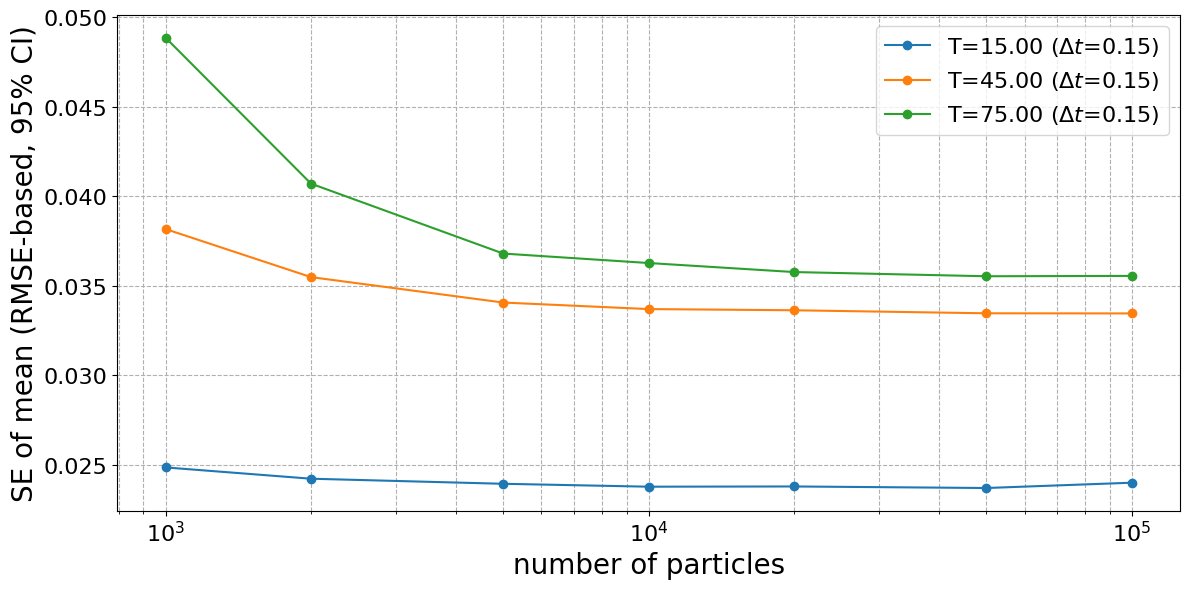

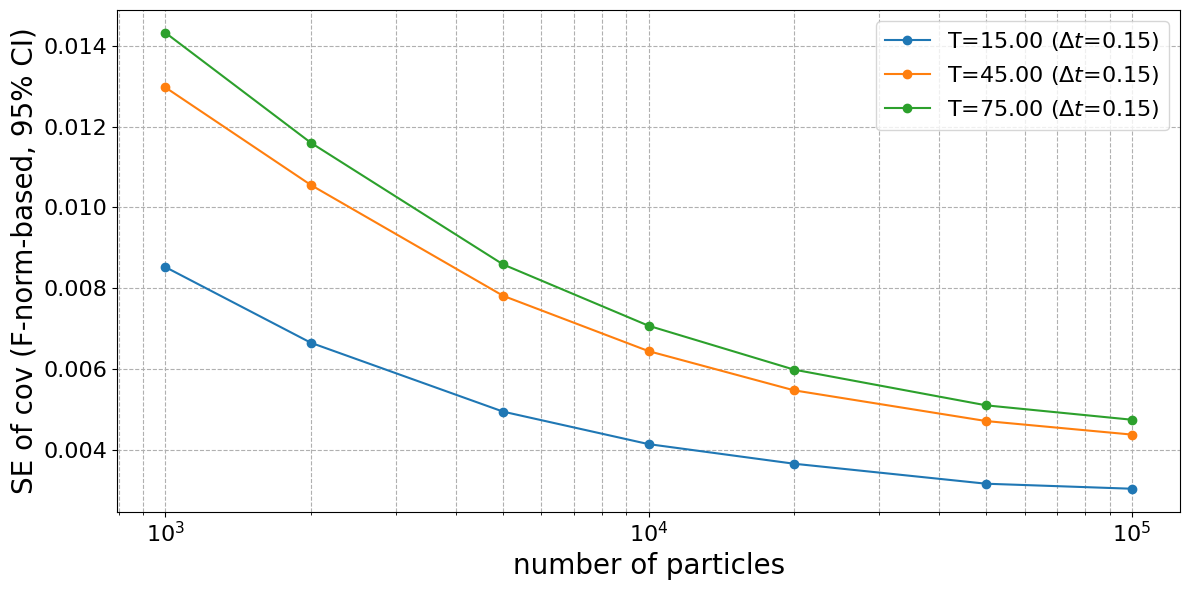

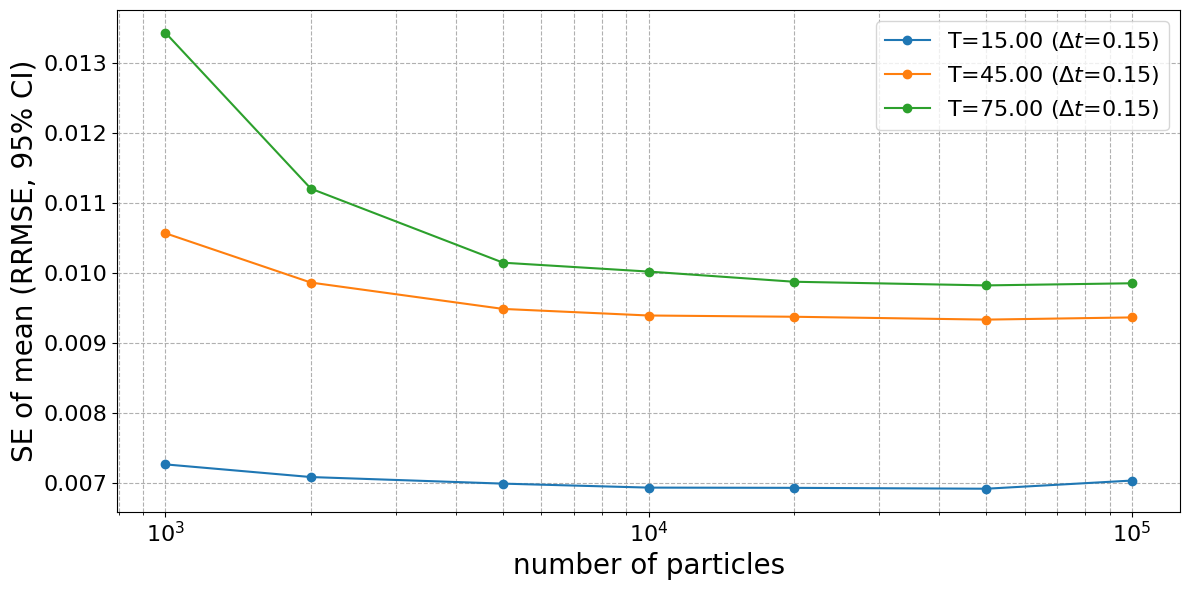

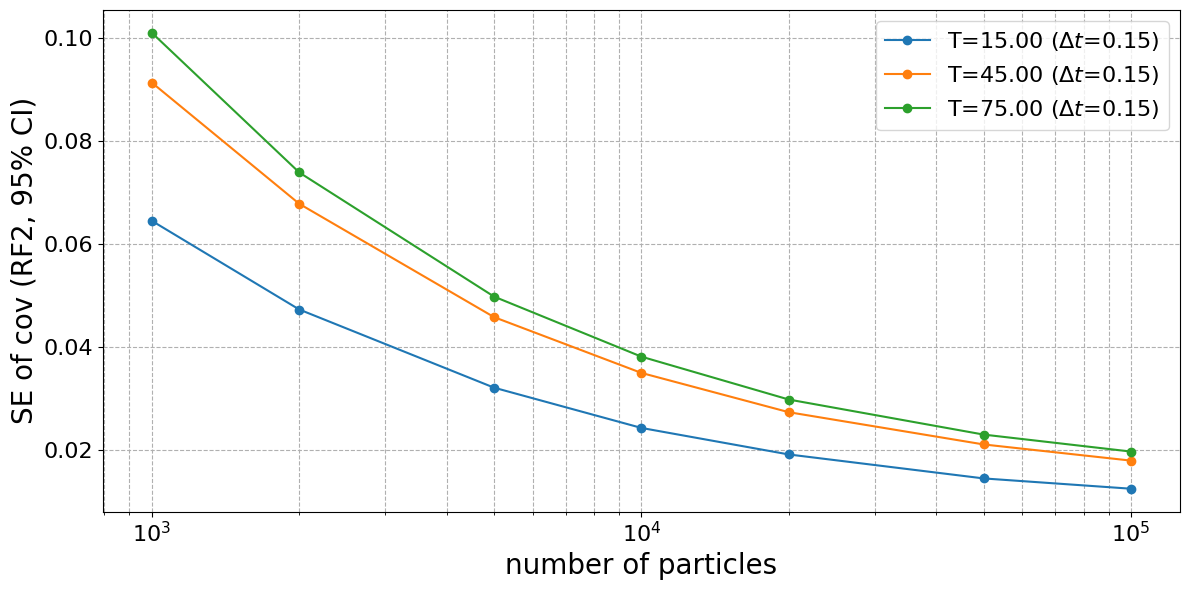


--- Plotting Complete ---


In [5]:
import torch
import os
import matplotlib.pyplot as plt
import math

# --- Configuration ---
pf_N_list = [1000, 2000, 5000, 10000, 20000, 50000, 100000]
seed_list = torch.arange(100)
max_t_list = [100, 300, 500]

# Make dataset name a variable and build data_dir via f-string
dataset = "rossler"
data_dir = f"data/{dataset}/"

dt = 0.15  # physical time step used only for legend labeling
eps = 1e-12  # small constant to avoid divide-by-zero in relative metrics

# --- Part 1: Average data across seeds and save new files ---
print("--- Starting Data Averaging Process ---")
os.makedirs(data_dir, exist_ok=True)

N_seeds = len(seed_list)

for pf_N in pf_N_list:
    mean_tensors = []
    cov_tensors = []

    for seed in seed_list:
        file_path = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_{seed}.pt"
        if os.path.exists(file_path):
            try:
                # NOTE: weights_only=True is fine if the file is a pure tensor container; otherwise consider removing it.
                data = torch.load(file_path, weights_only=True)
                mean_tensors.append(data[0]['means'])
                cov_tensors.append(data[0]['covs'])
            except Exception as e:
                print(f"Could not load or process file {file_path}: {e}")
        else:
            print(f"Warning: File not found and will be skipped: {file_path}")

    if not mean_tensors:
        print(f"No data found for pf_N = {pf_N}, skipping.")
        continue

    avg_mean = torch.mean(torch.stack(mean_tensors), dim=0)
    avg_cov = torch.mean(torch.stack(cov_tensors), dim=0)

    output_data = [{'means': avg_mean, 'covs': avg_cov}]
    output_path = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_avg.pt"
    torch.save(output_data, output_path)
    print(f"Successfully created: {output_path}")

print("\n--- Data Averaging Complete ---\n")

# --- Part 2: Calculate SE and Plot Results ---
print("--- Starting Plotting Process ---")

# Absolute metrics figures
fig1 = plt.figure(figsize=(12, 6))
fig2 = plt.figure(figsize=(12, 6))
ax1 = fig1.add_subplot(1, 1, 1)
ax2 = fig2.add_subplot(1, 1, 1)
ax1.set_xscale('log')
ax2.set_xscale('log')

# Relative metrics figures (NEW)
fig3 = plt.figure(figsize=(12, 6))
fig4 = plt.figure(figsize=(12, 6))
ax3 = fig3.add_subplot(1, 1, 1)
ax4 = fig4.add_subplot(1, 1, 1)
ax3.set_xscale('log')
ax4.set_xscale('log')

for max_t in max_t_list:
    SE_rmse_mean_list = []
    SE_rrmse_mean_list = []
    SE_f2_cov_list = []
    SE_rf2_cov_list = []

    for pf_N in pf_N_list:
        mean_list = []
        cov_list = []
        # Load all available seeds for this pf_N
        for seed in seed_list:
            data_name = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_{seed}.pt"
            if not os.path.exists(data_name):
                print(f"Warning: missing {data_name}, skip this seed.")
                continue
            data = torch.load(data_name, weights_only=True)
            mean_list.append(data[0]['means'])
            cov_list.append(data[0]['covs'])

        n_seeds_found = len(mean_list)
        if n_seeds_found < 2:
            # Need at least 2 seeds to form an unbiased sample variance
            print(f"Not enough seeds for pf_N={pf_N} (found {n_seeds_found}), skipping.")
            # Fill with NaN to keep list sizes aligned with pf_N_list
            SE_rmse_mean_list.append(float('nan'))
            SE_rrmse_mean_list.append(float('nan'))
            SE_f2_cov_list.append(float('nan'))
            SE_rf2_cov_list.append(float('nan'))
            continue

        # Stack tensors and truncate to max_t along time
        mean_tensor = torch.stack(mean_list)[:, :max_t, :, :]          # shape: (S, T, B, D)
        cov_tensor  = torch.stack(cov_list)[:, :max_t, :, :, :]        # shape: (S, T, B, D, D)

        # --- Mean metrics ---
        avg_mean_across_seeds = torch.mean(mean_tensor, dim=0, keepdim=True)  # (1, T, B, D)
        error_mean = mean_tensor - avg_mean_across_seeds                      # (S, T, B, D)

        # pointwise sample std across seeds: sqrt( sum(error^2) / (S-1) )
        std_mean = torch.sqrt(torch.sum(error_mean ** 2, dim=0) / (n_seeds_found - 1))  # (T, B, D)

        # standard error of the mean: std / sqrt(S)
        se_mean = std_mean / math.sqrt(n_seeds_found)                                  # (T, B, D)

        # 95% CI half-width
        ci_95_mean = 1.96 * se_mean                                                    # (T, B, D)

        # RMSE across state dimension -> (T, B)
        ci_95_rmse = torch.sqrt(torch.mean(ci_95_mean ** 2, dim=-1))                   # (T, B)
        SE_rmse_mean_list.append(ci_95_rmse.mean().item())

        # Relative RMSE: divide by RMS magnitude of the (across-seed) mean as a scale
        denom_mean = torch.sqrt(torch.mean(avg_mean_across_seeds.squeeze(0) ** 2, dim=-1))  # (T, B)
        rrmse = ci_95_rmse / (denom_mean + eps)                                             # (T, B)
        SE_rrmse_mean_list.append(rrmse.mean().item())

        # --- Covariance metrics ---
        avg_cov_across_seeds = torch.mean(cov_tensor, dim=0, keepdim=True)  # (1, T, B, D, D)
        error_cov = cov_tensor - avg_cov_across_seeds                        # (S, T, B, D, D)

        # pointwise sample std across seeds (elementwise on matrices)
        std_cov = torch.sqrt(torch.sum(error_cov ** 2, dim=0) / (n_seeds_found - 1))       # (T, B, D, D)

        # standard error of the mean covariance
        se_cov = std_cov / math.sqrt(n_seeds_found)                                        # (T, B, D, D)

        # 95% CI half-width (elementwise), then take Frobenius norm over matrix dims -> (T, B)
        ci_95_cov = 1.96 * se_cov
        ci_95_covf2 = torch.linalg.norm(ci_95_cov, ord='fro', dim=(-2, -1))               # (T, B)
        SE_f2_cov_list.append(ci_95_covf2.mean().item())

        # Relative Frobenius: divide by Frobenius norm of the across-seed mean covariance
        denom_cov = torch.linalg.norm(avg_cov_across_seeds.squeeze(0), ord='fro', dim=(-2, -1))  # (T, B)
        rf2 = ci_95_covf2 / (denom_cov + eps)                                                    # (T, B)
        SE_rf2_cov_list.append(rf2.mean().item())

        # Optional: print a quick sanity line for a large N
        T_physical = max_t * dt
        if pf_N == 100_000:
            print(f"Results for T={T_physical:.2f}, pf_N={pf_N}:")
            print(f"  SE of Mean (RMSE-based): {SE_rmse_mean_list[-1]:.6g}")
            print(f"  SE of Cov (F-norm-based): {SE_f2_cov_list[-1]:.6g}")
            print(f"  SE of Mean (Relative RMSE): {SE_rrmse_mean_list[-1]:.6g}")
            print(f"  SE of Cov (Relative F-norm): {SE_rf2_cov_list[-1]:.6g}")

    # Plot absolute metrics
    ax1.plot(pf_N_list, SE_rmse_mean_list, marker='o', linestyle='-',
            label=fr"T={max_t*dt:.2f} ($\Delta t$={dt})")
    ax2.plot(pf_N_list, SE_f2_cov_list, marker='o', linestyle='-',
            label=fr"T={max_t*dt:.2f} ($\Delta t$={dt})")

    # Plot relative metrics (NEW)
    ax3.plot(pf_N_list, SE_rrmse_mean_list, marker='o', linestyle='-',
            label=fr"T={max_t*dt:.2f} ($\Delta t$={dt})")
    ax4.plot(pf_N_list, SE_rf2_cov_list, marker='o', linestyle='-',
            label=fr"T={max_t*dt:.2f} ($\Delta t$={dt})")

# Labels and cosmetics for absolute metrics
ax1.set_xlabel("number of particles", fontsize=20)
ax1.set_ylabel("SE of mean (RMSE-based, 95% CI)", fontsize=20)
ax1.legend(fontsize=16)
ax1.tick_params(axis='both', which='major', labelsize=16)
ax1.grid(True, which="both", ls="--")

ax2.set_xlabel("number of particles", fontsize=20)
ax2.set_ylabel("SE of cov (F-norm-based, 95% CI)", fontsize=20)
ax2.legend(fontsize=16)
ax2.tick_params(axis='both', which='major', labelsize=16)
ax2.grid(True, which="both", ls="--")

# Labels and cosmetics for relative metrics (NEW)
ax3.set_xlabel("number of particles", fontsize=20)
ax3.set_ylabel("SE of mean (RRMSE, 95% CI)", fontsize=20)
ax3.legend(fontsize=16)
ax3.tick_params(axis='both', which='major', labelsize=16)
ax3.grid(True, which="both", ls="--")

ax4.set_xlabel("number of particles", fontsize=20)
ax4.set_ylabel("SE of cov (RF2, 95% CI)", fontsize=20)
ax4.legend(fontsize=16)
ax4.tick_params(axis='both', which='major', labelsize=16)
ax4.grid(True, which="both", ls="--")

fig1.tight_layout()
fig2.tight_layout()
fig3.tight_layout()
fig4.tight_layout()

plt.show()

print("\n--- Plotting Complete ---")


--- Starting Data Averaging Process ---
Successfully created: data/lorenz96/pf_results_sigma_y_1.0_batch_64_len_500_pfN_1000_avg.pt
Successfully created: data/lorenz96/pf_results_sigma_y_1.0_batch_64_len_500_pfN_2000_avg.pt
Successfully created: data/lorenz96/pf_results_sigma_y_1.0_batch_64_len_500_pfN_5000_avg.pt
Successfully created: data/lorenz96/pf_results_sigma_y_1.0_batch_64_len_500_pfN_10000_avg.pt
Successfully created: data/lorenz96/pf_results_sigma_y_1.0_batch_64_len_500_pfN_20000_avg.pt
Successfully created: data/lorenz96/pf_results_sigma_y_1.0_batch_64_len_500_pfN_50000_avg.pt
Successfully created: data/lorenz96/pf_results_sigma_y_1.0_batch_64_len_500_pfN_100000_avg.pt
Successfully created: data/lorenz96/pf_results_sigma_y_1.0_batch_64_len_500_pfN_200000_avg.pt
Successfully created: data/lorenz96/pf_results_sigma_y_1.0_batch_64_len_500_pfN_500000_avg.pt
Successfully created: data/lorenz96/pf_results_sigma_y_1.0_batch_64_len_500_pfN_1000000_avg.pt

--- Data Averaging Complete

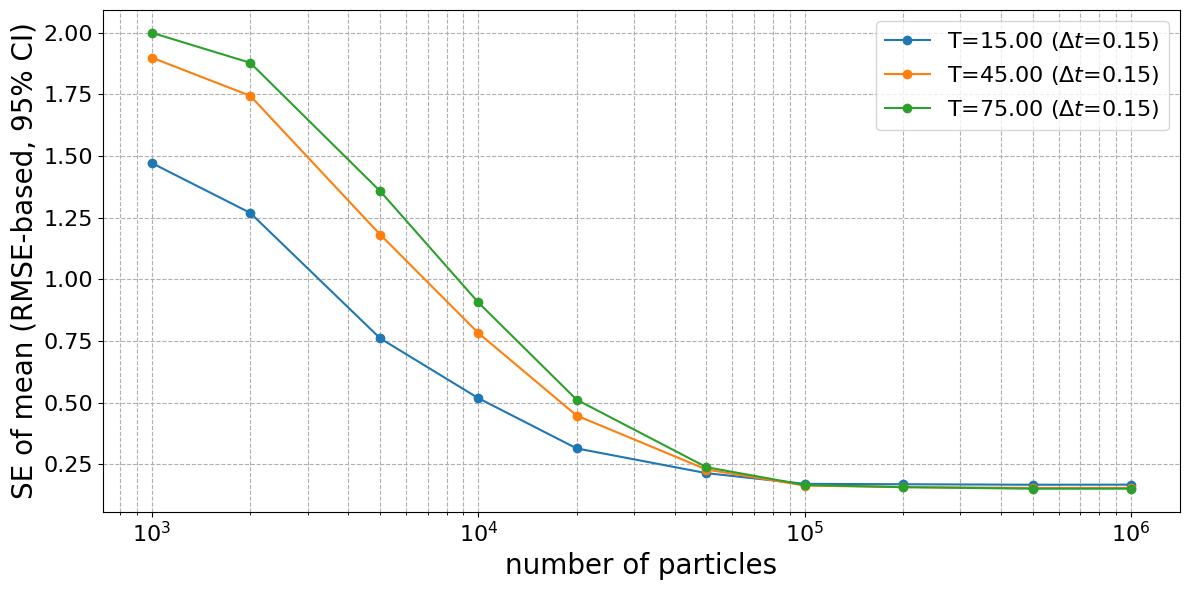

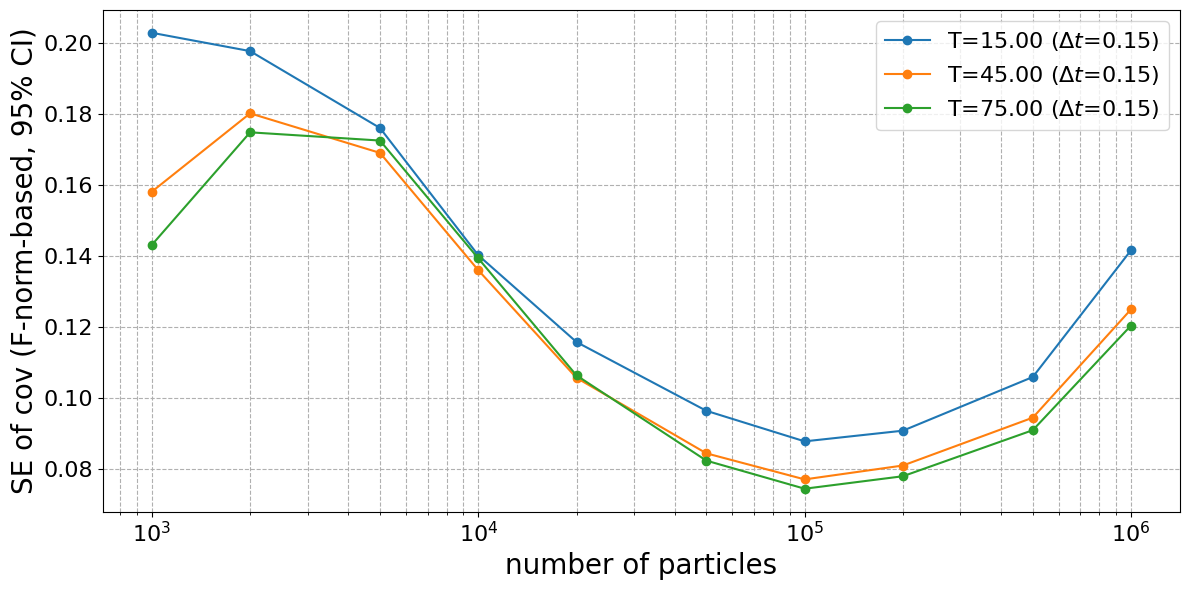

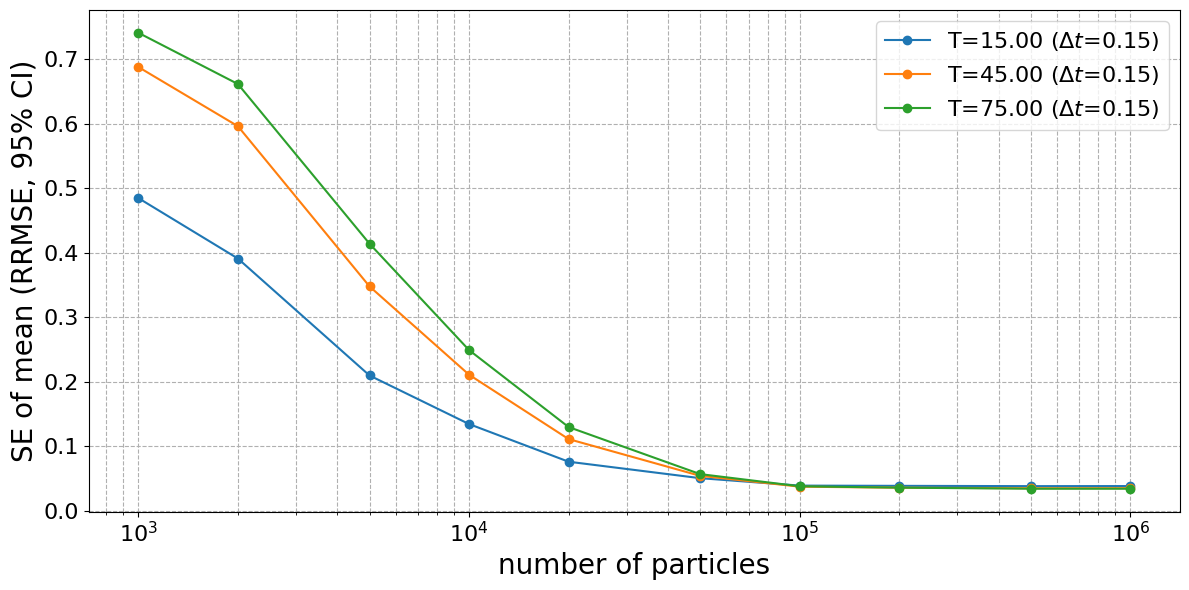

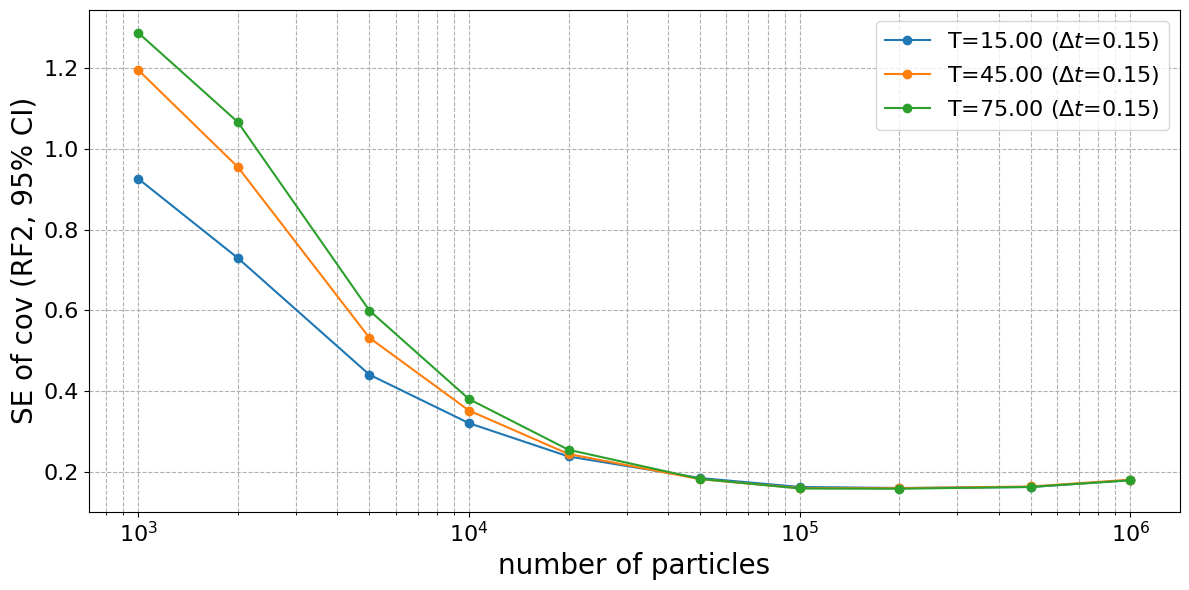


--- Plotting Complete ---


In [ ]:
import torch
import os
import matplotlib.pyplot as plt
import math

# --- Configuration ---
pf_N_list = [1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000]
seed_list = torch.arange(100)
max_t_list = [100, 300, 500]

# Make dataset name a variable and build data_dir via f-string
dataset = "lorenz96"
data_dir = f"data/{dataset}/"

dt = 0.15  # physical time step used only for legend labeling
eps = 1e-12  # small constant to avoid divide-by-zero in relative metrics

# --- Part 1: Average data across seeds and save new files ---
print("--- Starting Data Averaging Process ---")
os.makedirs(data_dir, exist_ok=True)

N_seeds = len(seed_list)

for pf_N in pf_N_list:
    mean_tensors = []
    cov_tensors = []

    for seed in seed_list:
        file_path = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_{seed}.pt"
        if os.path.exists(file_path):
            try:
                # NOTE: weights_only=True is fine if the file is a pure tensor container; otherwise consider removing it.
                data = torch.load(file_path, weights_only=True)
                mean_tensors.append(data[0]['means'])
                cov_tensors.append(data[0]['covs'])
            except Exception as e:
                print(f"Could not load or process file {file_path}: {e}")
        else:
            print(f"Warning: File not found and will be skipped: {file_path}")

    if not mean_tensors:
        print(f"No data found for pf_N = {pf_N}, skipping.")
        continue

    avg_mean = torch.mean(torch.stack(mean_tensors), dim=0)
    avg_cov = torch.mean(torch.stack(cov_tensors), dim=0)

    output_data = [{'means': avg_mean, 'covs': avg_cov}]
    output_path = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_avg.pt"
    torch.save(output_data, output_path)
    print(f"Successfully created: {output_path}")

print("\n--- Data Averaging Complete ---\n")

# --- Part 2: Calculate SE and Plot Results ---
print("--- Starting Plotting Process ---")

# Absolute metrics figures
fig1 = plt.figure(figsize=(12, 6))
fig2 = plt.figure(figsize=(12, 6))
ax1 = fig1.add_subplot(1, 1, 1)
ax2 = fig2.add_subplot(1, 1, 1)
ax1.set_xscale('log')
ax2.set_xscale('log')

# Relative metrics figures (NEW)
fig3 = plt.figure(figsize=(12, 6))
fig4 = plt.figure(figsize=(12, 6))
ax3 = fig3.add_subplot(1, 1, 1)
ax4 = fig4.add_subplot(1, 1, 1)
ax3.set_xscale('log')
ax4.set_xscale('log')

for max_t in max_t_list:
    SE_rmse_mean_list = []
    SE_rrmse_mean_list = []
    SE_f2_cov_list = []
    SE_rf2_cov_list = []

    for pf_N in pf_N_list:
        mean_list = []
        cov_list = []
        # Load all available seeds for this pf_N
        for seed in seed_list:
            data_name = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_{seed}.pt"
            if not os.path.exists(data_name):
                print(f"Warning: missing {data_name}, skip this seed.")
                continue
            data = torch.load(data_name, weights_only=True)
            mean_list.append(data[0]['means'])
            cov_list.append(data[0]['covs'])

        n_seeds_found = len(mean_list)
        if n_seeds_found < 2:
            # Need at least 2 seeds to form an unbiased sample variance
            print(f"Not enough seeds for pf_N={pf_N} (found {n_seeds_found}), skipping.")
            # Fill with NaN to keep list sizes aligned with pf_N_list
            SE_rmse_mean_list.append(float('nan'))
            SE_rrmse_mean_list.append(float('nan'))
            SE_f2_cov_list.append(float('nan'))
            SE_rf2_cov_list.append(float('nan'))
            continue

        # Stack tensors and truncate to max_t along time
        mean_tensor = torch.stack(mean_list)[:, :max_t, :, :]          # shape: (S, T, B, D)
        cov_tensor  = torch.stack(cov_list)[:, :max_t, :, :, :]        # shape: (S, T, B, D, D)

        # --- Mean metrics ---
        avg_mean_across_seeds = torch.mean(mean_tensor, dim=0, keepdim=True)  # (1, T, B, D)
        error_mean = mean_tensor - avg_mean_across_seeds                      # (S, T, B, D)

        # pointwise sample std across seeds: sqrt( sum(error^2) / (S-1) )
        std_mean = torch.sqrt(torch.sum(error_mean ** 2, dim=0) / (n_seeds_found - 1))  # (T, B, D)

        # standard error of the mean: std / sqrt(S)
        se_mean = std_mean / math.sqrt(n_seeds_found)                                  # (T, B, D)

        # 95% CI half-width
        ci_95_mean = 1.96 * se_mean                                                    # (T, B, D)

        # RMSE across state dimension -> (T, B)
        ci_95_rmse = torch.sqrt(torch.mean(ci_95_mean ** 2, dim=-1))                   # (T, B)
        SE_rmse_mean_list.append(ci_95_rmse.mean().item())

        # Relative RMSE: divide by RMS magnitude of the (across-seed) mean as a scale
        denom_mean = torch.sqrt(torch.mean(avg_mean_across_seeds.squeeze(0) ** 2, dim=-1))  # (T, B)
        rrmse = ci_95_rmse / (denom_mean + eps)                                             # (T, B)
        SE_rrmse_mean_list.append(rrmse.mean().item())

        # --- Covariance metrics ---
        avg_cov_across_seeds = torch.mean(cov_tensor, dim=0, keepdim=True)  # (1, T, B, D, D)
        error_cov = cov_tensor - avg_cov_across_seeds                        # (S, T, B, D, D)

        # pointwise sample std across seeds (elementwise on matrices)
        std_cov = torch.sqrt(torch.sum(error_cov ** 2, dim=0) / (n_seeds_found - 1))       # (T, B, D, D)

        # standard error of the mean covariance
        se_cov = std_cov / math.sqrt(n_seeds_found)                                        # (T, B, D, D)

        # 95% CI half-width (elementwise), then take Frobenius norm over matrix dims -> (T, B)
        ci_95_cov = 1.96 * se_cov
        ci_95_covf2 = torch.linalg.norm(ci_95_cov, ord='fro', dim=(-2, -1))               # (T, B)
        SE_f2_cov_list.append(ci_95_covf2.mean().item())

        # Relative Frobenius: divide by Frobenius norm of the across-seed mean covariance
        denom_cov = torch.linalg.norm(avg_cov_across_seeds.squeeze(0), ord='fro', dim=(-2, -1))  # (T, B)
        rf2 = ci_95_covf2 / (denom_cov + eps)                                                    # (T, B)
        SE_rf2_cov_list.append(rf2.mean().item())

        # Optional: print a quick sanity line for a large N
        T_physical = max_t * dt
        if pf_N == 1_000_000:
            print(f"Results for T={T_physical:.2f}, pf_N={pf_N}:")
            print(f"  SE of Mean (RMSE-based): {SE_rmse_mean_list[-1]:.6g}")
            print(f"  SE of Cov (F-norm-based): {SE_f2_cov_list[-1]:.6g}")
            print(f"  SE of Mean (Relative RMSE): {SE_rrmse_mean_list[-1]:.6g}")
            print(f"  SE of Cov (Relative F-norm): {SE_rf2_cov_list[-1]:.6g}")

    # Plot absolute metrics
    ax1.plot(pf_N_list, SE_rmse_mean_list, marker='o', linestyle='-',
            label=fr"T={max_t*dt:.2f} ($\Delta t$={dt})")
    ax2.plot(pf_N_list, SE_f2_cov_list, marker='o', linestyle='-',
            label=fr"T={max_t*dt:.2f} ($\Delta t$={dt})")

    # Plot relative metrics (NEW)
    ax3.plot(pf_N_list, SE_rrmse_mean_list, marker='o', linestyle='-',
            label=fr"T={max_t*dt:.2f} ($\Delta t$={dt})")
    ax4.plot(pf_N_list, SE_rf2_cov_list, marker='o', linestyle='-',
            label=fr"T={max_t*dt:.2f} ($\Delta t$={dt})")

# Labels and cosmetics for absolute metrics
ax1.set_xlabel("number of particles", fontsize=20)
ax1.set_ylabel("SE of mean (RMSE-based, 95% CI)", fontsize=20)
ax1.legend(fontsize=16)
ax1.tick_params(axis='both', which='major', labelsize=16)
ax1.grid(True, which="both", ls="--")

ax2.set_xlabel("number of particles", fontsize=20)
ax2.set_ylabel("SE of cov (F-norm-based, 95% CI)", fontsize=20)
ax2.legend(fontsize=16)
ax2.tick_params(axis='both', which='major', labelsize=16)
ax2.grid(True, which="both", ls="--")

# Labels and cosmetics for relative metrics (NEW)
ax3.set_xlabel("number of particles", fontsize=20)
ax3.set_ylabel("SE of mean (RRMSE, 95% CI)", fontsize=20)
ax3.legend(fontsize=16)
ax3.tick_params(axis='both', which='major', labelsize=16)
ax3.grid(True, which="both", ls="--")

ax4.set_xlabel("number of particles", fontsize=20)
ax4.set_ylabel("SE of cov (RF2, 95% CI)", fontsize=20)
ax4.legend(fontsize=16)
ax4.tick_params(axis='both', which='major', labelsize=16)
ax4.grid(True, which="both", ls="--")

fig1.tight_layout()
fig2.tight_layout()
fig3.tight_layout()
fig4.tight_layout()

plt.show()

print("\n--- Plotting Complete ---")


--- Starting Data Averaging Process ---
Successfully created: data/circle/pf_results_sigma_y_1.0_batch_64_len_500_pfN_1000_avg.pt
Successfully created: data/circle/pf_results_sigma_y_1.0_batch_64_len_500_pfN_2000_avg.pt
Successfully created: data/circle/pf_results_sigma_y_1.0_batch_64_len_500_pfN_5000_avg.pt
Successfully created: data/circle/pf_results_sigma_y_1.0_batch_64_len_500_pfN_10000_avg.pt
Successfully created: data/circle/pf_results_sigma_y_1.0_batch_64_len_500_pfN_20000_avg.pt
Successfully created: data/circle/pf_results_sigma_y_1.0_batch_64_len_500_pfN_50000_avg.pt
Successfully created: data/circle/pf_results_sigma_y_1.0_batch_64_len_500_pfN_100000_avg.pt
Successfully created: data/circle/pf_results_sigma_y_1.0_batch_64_len_500_pfN_200000_avg.pt
Successfully created: data/circle/pf_results_sigma_y_1.0_batch_64_len_500_pfN_500000_avg.pt
Successfully created: data/circle/pf_results_sigma_y_1.0_batch_64_len_500_pfN_1000000_avg.pt

--- Data Averaging Complete ---

--- Starting P

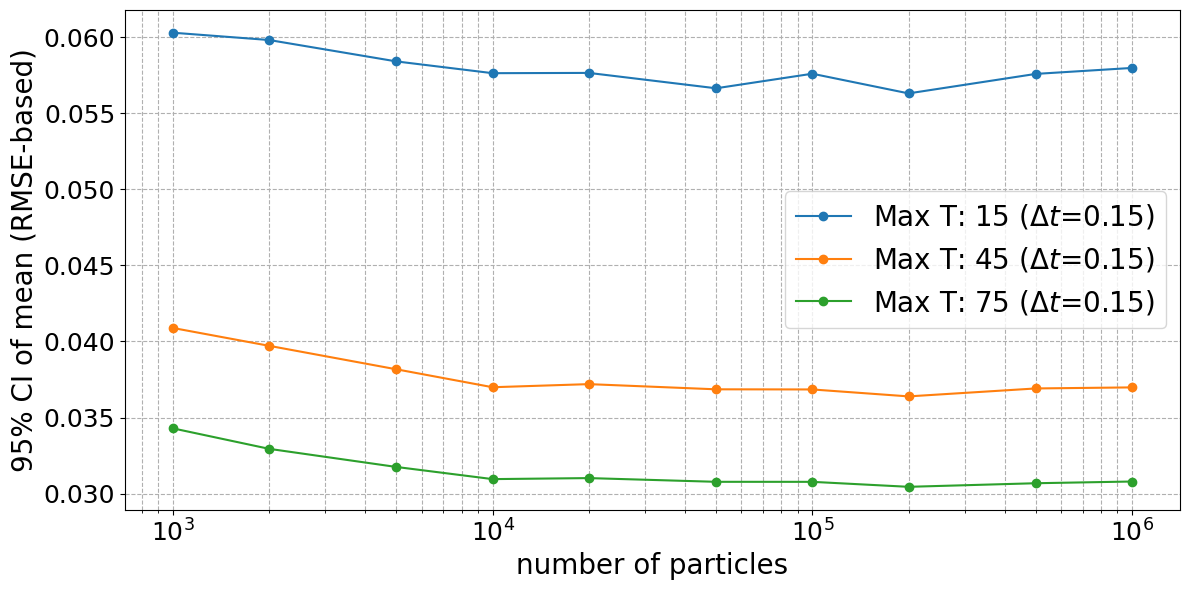

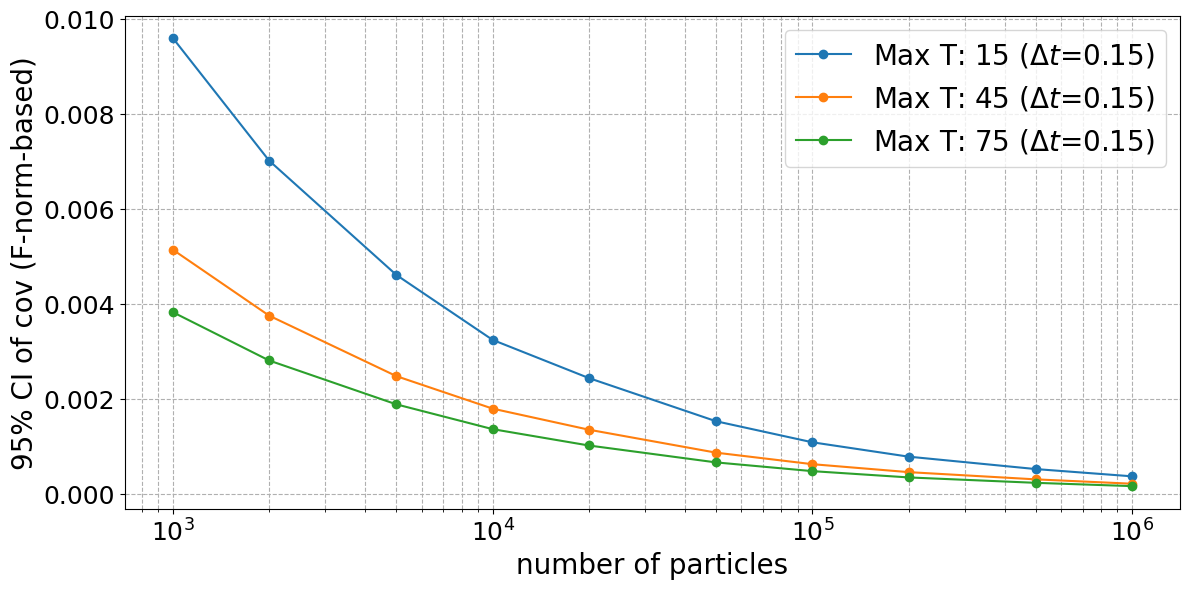


--- Plotting Complete ---


In [ ]:
max_t_list = [100, 300, 500]
data_dir = "data/circle/"

# --- Part 1: Average data across seeds and save new files ---
print("--- Starting Data Averaging Process ---")
os.makedirs(data_dir, exist_ok=True)

for pf_N in pf_N_list:
    mean_tensors = []
    cov_tensors = []

    for seed in seed_list:
        file_path = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_{seed}.pt"
        
        if os.path.exists(file_path):
            try:
                data = torch.load(file_path, weights_only=True)
                mean_tensors.append(data[0]['means'])
                cov_tensors.append(data[0]['covs'])
            except Exception as e:
                print(f"Could not load or process file {file_path}: {e}")
        else:
            print(f"Warning: File not found and will be skipped: {file_path}")

    if not mean_tensors:
        print(f"No data found for pf_N = {pf_N}, skipping.")
        continue

    avg_mean = torch.mean(torch.stack(mean_tensors), dim=0)
    avg_cov = torch.mean(torch.stack(cov_tensors), dim=0)

    output_data = [{'means': avg_mean, 'covs': avg_cov}]
    
    output_path = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_avg.pt"
    torch.save(output_data, output_path)
    
    print(f"Successfully created: {output_path}")

print("\n--- Data Averaging Complete ---\n")


# --- Part 2: Calculate SE and Plot Results ---
print("--- Starting Plotting Process ---")

fig1 = plt.figure(figsize=(12, 6))
fig2 = plt.figure(figsize=(12, 6))
ax1 = fig1.add_subplot(1, 1, 1)
ax2 = fig2.add_subplot(1, 1, 1)
ax1.set_xscale('log')
ax2.set_xscale('log')

num_seeds = len(seed_list)

for max_t in max_t_list:
    SE_mean_list = []
    SE_cov_list = []
    for pf_N in pf_N_list:
        mean_list = []
        cov_list =[]
        for seed in seed_list:
            data_name = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_{seed}.pt"
            data = torch.load(data_name, weights_only=True)
            mean_list.append(data[0]['means'])
            cov_list.append(data[0]['covs'])
            
        mean_tensor = torch.stack(mean_list)[:, :max_t, :, :]
        cov_tensor = torch.stack(cov_list)[:, :max_t, :, :]
        
        avg_mean_across_seeds = torch.mean(mean_tensor, dim=0, keepdim=True)
        error_mean = mean_tensor - avg_mean_across_seeds
        rmse_tensor = torch.sqrt(torch.mean(error_mean**2, dim=-1))
        se_of_rmse = torch.std(rmse_tensor, dim=0) / math.sqrt(num_seeds)
        SE_mean_list.append( se_of_rmse.mean().item())

        avg_cov_across_seeds = torch.mean(cov_tensor, dim=0, keepdim=True)
        error_cov = cov_tensor - avg_cov_across_seeds
        fnorm_tensor = torch.linalg.norm(error_cov, ord='fro', dim=(-2, -1))
        se_of_fnorm = torch.std(fnorm_tensor, dim=0) / math.sqrt(num_seeds)
        SE_cov_list.append( se_of_fnorm.mean().item())

        max_T = int(max_t * 0.15)
        if pf_N == 1000000:
            print(f"Results for max_t={max_T}, pf_N={pf_N}:")
            print(f"  SE of Mean (RMSE-based): {SE_mean_list[-1]}")
            print(f"  SE of Cov (F-norm-based): {SE_cov_list[-1]}")
            
    ax1.plot(pf_N_list, SE_mean_list, marker='o', linestyle='-', label=fr"Max T: {max_T} ($\Delta t$=0.15)")
    ax2.plot(pf_N_list, SE_cov_list, marker='o', linestyle='-', label=fr"Max T: {max_T} ($\Delta t$=0.15)")

ax1.set_xlabel("number of particles", fontsize=20)
ax1.set_ylabel("SE of mean (RMSE-based)", fontsize=20)
ax1.legend(fontsize=20)
ax1.tick_params(axis='both', which='major', labelsize=18)
ax1.grid(True, which="both", ls="--")

ax2.set_xlabel("number of particles", fontsize=20)
ax2.set_ylabel("SE of cov (F-norm-based)", fontsize=20)
ax2.legend(fontsize=20)
ax2.tick_params(axis='both', which='major', labelsize=18)
ax2.grid(True, which="both", ls="--")

fig1.tight_layout()
fig2.tight_layout()

plt.show()

print("\n--- Plotting Complete ---")

In [ ]:
max_t_list = [100, 300, 500]
data_dir = "data/circle/"

# --- Part 1: Average data across seeds and save new files ---
print("--- Starting Data Averaging Process ---")
os.makedirs(data_dir, exist_ok=True)

for pf_N in pf_N_list:
    mean_tensors = []
    cov_tensors = []

    for seed in seed_list:
        file_path = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_{seed}.pt"
        
        if os.path.exists(file_path):
            try:
                data = torch.load(file_path, weights_only=True)
                mean_tensors.append(data[0]['means'])
                cov_tensors.append(data[0]['covs'])
            except Exception as e:
                print(f"Could not load or process file {file_path}: {e}")
        else:
            print(f"Warning: File not found and will be skipped: {file_path}")

    if not mean_tensors:
        print(f"No data found for pf_N = {pf_N}, skipping.")
        continue

    avg_mean = torch.mean(torch.stack(mean_tensors), dim=0)
    avg_cov = torch.mean(torch.stack(cov_tensors), dim=0)

    output_data = [{'means': avg_mean, 'covs': avg_cov}]
    
    output_path = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_avg.pt"
    torch.save(output_data, output_path)
    
    print(f"Successfully created: {output_path}")

print("\n--- Data Averaging Complete ---\n")


# --- Part 2: Calculate 95% CI and Plot Results ---
print("--- Starting Plotting Process ---")

fig1 = plt.figure(figsize=(12, 6))
fig2 = plt.figure(figsize=(12, 6))
ax1 = fig1.add_subplot(1, 1, 1)
ax2 = fig2.add_subplot(1, 1, 1)
ax1.set_xscale('log')
ax2.set_xscale('log')

num_seeds = len(seed_list)

for max_t in max_t_list:
    SE_mean_list = []
    SE_cov_list = []
    for pf_N in pf_N_list:
        mean_list = []
        cov_list =[]
        for seed in seed_list:
            data_name = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_{seed}.pt"
            data = torch.load(data_name, weights_only=True)
            mean_list.append(data[0]['means'])
            cov_list.append(data[0]['covs'])
            
        mean_tensor = torch.stack(mean_list)[:, :max_t, :, :]
        cov_tensor = torch.stack(cov_list)[:, :max_t, :, :]
        
        avg_mean_across_seeds = torch.mean(mean_tensor, dim=0, keepdim=True)
        error_mean = mean_tensor - avg_mean_across_seeds
        rmse_tensor = torch.sqrt(torch.mean(error_mean**2, dim=-1))
        se_of_rmse = torch.std(rmse_tensor, dim=0) / math.sqrt(num_seeds)
        SE_mean_list.append( se_of_rmse.mean().item())

        avg_cov_across_seeds = torch.mean(cov_tensor, dim=0, keepdim=True)
        error_cov = cov_tensor - avg_cov_across_seeds
        fnorm_tensor = torch.linalg.norm(error_cov, ord='fro', dim=(-2, -1))
        se_of_fnorm = torch.std(fnorm_tensor, dim=0) / math.sqrt(num_seeds)
        SE_cov_list.append( se_of_fnorm.mean().item())

        max_T = int(max_t * 0.15)
        if pf_N == 1000000:
            print(f"Results for max_t={max_T}, pf_N={pf_N}:")
            print(f"  95% CI of Mean (RMSE-based): {SE_mean_list[-1]}")
            print(f"  95% CI of Cov (F-norm-based): {SE_cov_list[-1]}")
            
    ax1.plot(pf_N_list, SE_mean_list, marker='o', linestyle='-', label=fr"Max T: {max_T} ($\Delta t$=0.15)")
    ax2.plot(pf_N_list, SE_cov_list, marker='o', linestyle='-', label=fr"Max T: {max_T} ($\Delta t$=0.15)")

ax1.set_xlabel("number of particles", fontsize=20)
ax1.set_ylabel("95% CI of mean (RMSE-based)", fontsize=20)
ax1.legend(fontsize=20)
ax1.tick_params(axis='both', which='major', labelsize=18)
ax1.grid(True, which="both", ls="--")

ax2.set_xlabel("number of particles", fontsize=20)
ax2.set_ylabel("95% CI of cov (F-norm-based)", fontsize=20)
ax2.legend(fontsize=20)
ax2.tick_params(axis='both', which='major', labelsize=18)
ax2.grid(True, which="both", ls="--")

fig1.tight_layout()
fig2.tight_layout()

plt.show()

print("\n--- Plotting Complete ---")

--- Starting Data Averaging Process ---
Successfully created: data/Hdoublewell/pf_results_sigma_y_1.0_batch_64_len_500_pfN_1000_avg.pt
Successfully created: data/Hdoublewell/pf_results_sigma_y_1.0_batch_64_len_500_pfN_2000_avg.pt
Successfully created: data/Hdoublewell/pf_results_sigma_y_1.0_batch_64_len_500_pfN_5000_avg.pt
Successfully created: data/Hdoublewell/pf_results_sigma_y_1.0_batch_64_len_500_pfN_10000_avg.pt
Successfully created: data/Hdoublewell/pf_results_sigma_y_1.0_batch_64_len_500_pfN_20000_avg.pt
Successfully created: data/Hdoublewell/pf_results_sigma_y_1.0_batch_64_len_500_pfN_50000_avg.pt
Successfully created: data/Hdoublewell/pf_results_sigma_y_1.0_batch_64_len_500_pfN_100000_avg.pt
Successfully created: data/Hdoublewell/pf_results_sigma_y_1.0_batch_64_len_500_pfN_200000_avg.pt
Successfully created: data/Hdoublewell/pf_results_sigma_y_1.0_batch_64_len_500_pfN_500000_avg.pt
Successfully created: data/Hdoublewell/pf_results_sigma_y_1.0_batch_64_len_500_pfN_1000000_avg.p

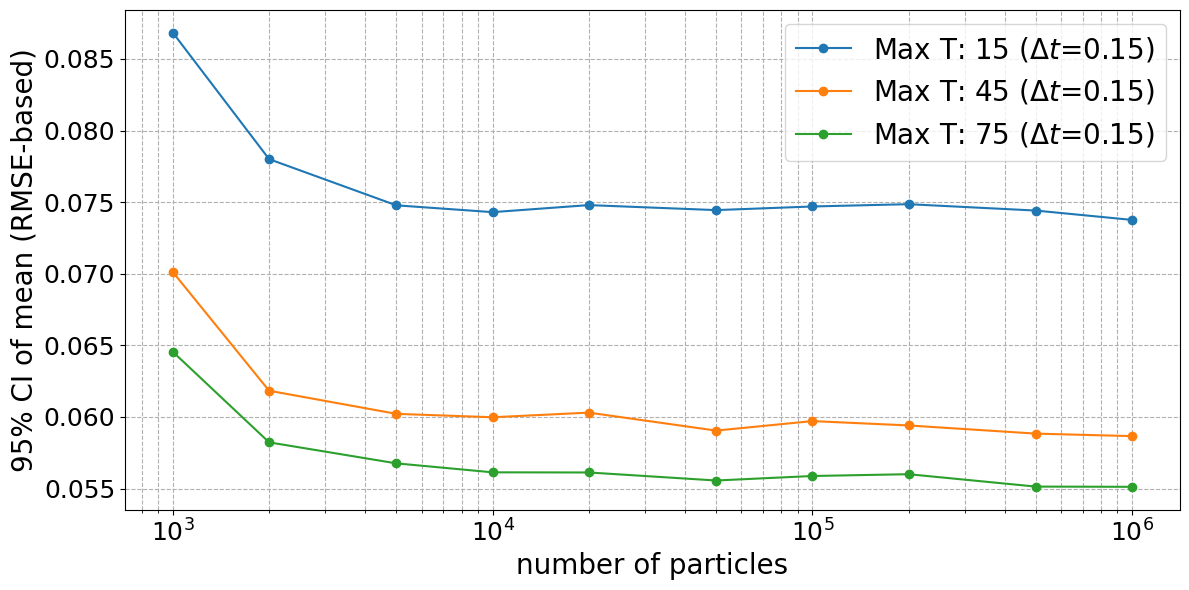

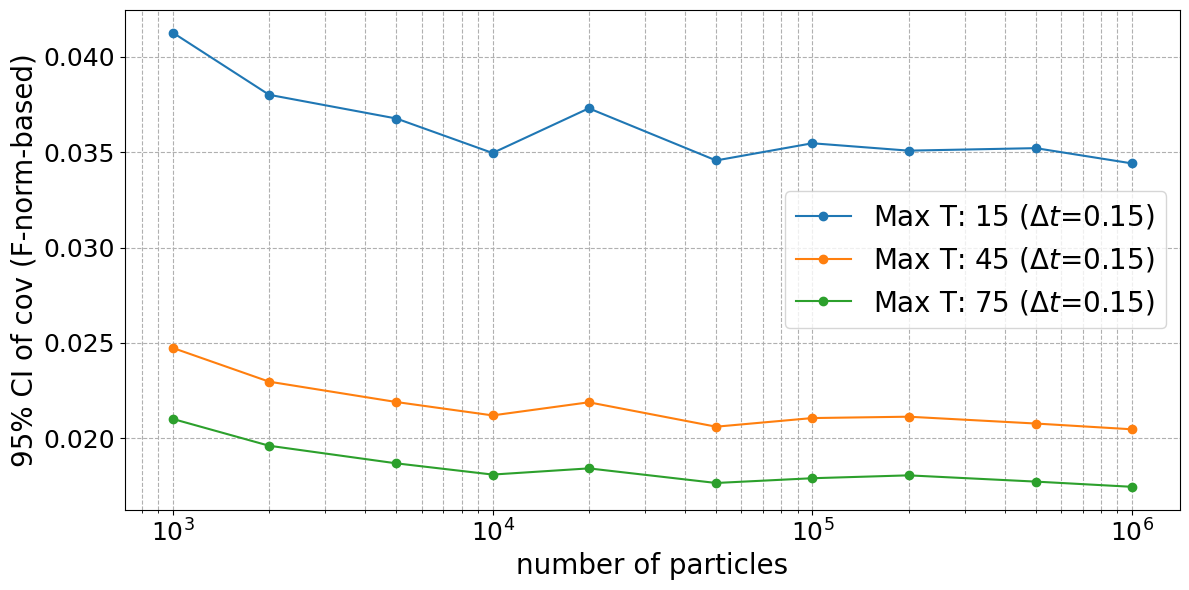


--- Plotting Complete ---


In [ ]:
max_t_list = [100, 300, 500]
data_dir = "data/Hdoublewell/"

# --- Part 1: Average data across seeds and save new files ---
print("--- Starting Data Averaging Process ---")
os.makedirs(data_dir, exist_ok=True)

for pf_N in pf_N_list:
    mean_tensors = []
    cov_tensors = []

    for seed in seed_list:
        file_path = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_{seed}.pt"
        
        if os.path.exists(file_path):
            try:
                data = torch.load(file_path, weights_only=True)
                mean_tensors.append(data[0]['means'])
                cov_tensors.append(data[0]['covs'])
            except Exception as e:
                print(f"Could not load or process file {file_path}: {e}")
        else:
            print(f"Warning: File not found and will be skipped: {file_path}")

    if not mean_tensors:
        print(f"No data found for pf_N = {pf_N}, skipping.")
        continue

    avg_mean = torch.mean(torch.stack(mean_tensors), dim=0)
    avg_cov = torch.mean(torch.stack(cov_tensors), dim=0)

    output_data = [{'means': avg_mean, 'covs': avg_cov}]
    
    output_path = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_avg.pt"
    torch.save(output_data, output_path)
    
    print(f"Successfully created: {output_path}")

print("\n--- Data Averaging Complete ---\n")


# --- Part 2: Calculate 95% CI and Plot Results ---
print("--- Starting Plotting Process ---")

fig1 = plt.figure(figsize=(12, 6))
fig2 = plt.figure(figsize=(12, 6))
ax1 = fig1.add_subplot(1, 1, 1)
ax2 = fig2.add_subplot(1, 1, 1)
ax1.set_xscale('log')
ax2.set_xscale('log')

num_seeds = len(seed_list)

for max_t in max_t_list:
    SE_mean_list = []
    SE_cov_list = []
    for pf_N in pf_N_list:
        mean_list = []
        cov_list =[]
        for seed in seed_list:
            data_name = f"{data_dir}pf_results_sigma_y_1.0_batch_64_len_500_pfN_{pf_N}_{seed}.pt"
            data = torch.load(data_name, weights_only=True)
            mean_list.append(data[0]['means'])
            cov_list.append(data[0]['covs'])
            
        mean_tensor = torch.stack(mean_list)[:, :max_t, :, :]
        cov_tensor = torch.stack(cov_list)[:, :max_t, :, :]
        
        avg_mean_across_seeds = torch.mean(mean_tensor, dim=0, keepdim=True)
        error_mean = mean_tensor - avg_mean_across_seeds
        rmse_tensor = torch.sqrt(torch.mean(error_mean**2, dim=-1))
        se_of_rmse = torch.std(rmse_tensor, dim=0) / math.sqrt(num_seeds)
        SE_mean_list.append( se_of_rmse.mean().item())

        avg_cov_across_seeds = torch.mean(cov_tensor, dim=0, keepdim=True)
        error_cov = cov_tensor - avg_cov_across_seeds
        fnorm_tensor = torch.linalg.norm(error_cov, ord='fro', dim=(-2, -1))
        se_of_fnorm = torch.std(fnorm_tensor, dim=0) / math.sqrt(num_seeds)
        SE_cov_list.append( se_of_fnorm.mean().item())

        max_T = int(max_t * 0.15)
        if pf_N == 1000000:
            print(f"Results for max_t={max_T}, pf_N={pf_N}:")
            print(f"  95% CI of Mean (RMSE-based): {SE_mean_list[-1]}")
            print(f"  95% CI of Cov (F-norm-based): {SE_cov_list[-1]}")
            
    ax1.plot(pf_N_list, SE_mean_list, marker='o', linestyle='-', label=fr"Max T: {max_T} ($\Delta t$=0.15)")
    ax2.plot(pf_N_list, SE_cov_list, marker='o', linestyle='-', label=fr"Max T: {max_T} ($\Delta t$=0.15)")

ax1.set_xlabel("number of particles", fontsize=20)
ax1.set_ylabel("95% CI of mean (RMSE-based)", fontsize=20)
ax1.legend(fontsize=20)
ax1.tick_params(axis='both', which='major', labelsize=18)
ax1.grid(True, which="both", ls="--")

ax2.set_xlabel("number of particles", fontsize=20)
ax2.set_ylabel("95% CI of cov (F-norm-based)", fontsize=20)
ax2.legend(fontsize=20)
ax2.tick_params(axis='both', which='major', labelsize=18)
ax2.grid(True, which="both", ls="--")

fig1.tight_layout()
fig2.tight_layout()

plt.show()

print("\n--- Plotting Complete ---")